<a href="https://colab.research.google.com/github/adadebea/cs4379-assignment1/blob/analysis-notebook/notebooks/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Netflix Titles Data Analysis
## Karen Nyadu - CS4379G Data Analysis & Visualization

## Problem Statement
This analysis investigates two research questions about Netflix's content library:

1. **How has the number of titles added to Netflix changed over time (by year)?**
   - This will show Netflix's growth pattern and content addition strategy over the years.

2. **Do Movies and TV Shows differ in ratings distribution?**
   - This compares content ratings (TV-MA, TV-14, PG-13, etc.) between Movies and TV Shows to see if there are differences in target audiences.

In [5]:
# 1. IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


In [8]:
# 2. DATA LOADING
from google.colab import files
print("Please upload your netflix_titles.csv file:")
uploaded = files.upload()

# Get the filename
filename = list(uploaded.keys())[0]
print(f"\nLoading file: {filename}")

# Load the dataset
df = pd.read_csv(filename)

# Display basic info
print(f"\nDataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()

Please upload your netflix_titles.csv file:


Saving netflix_titles.csv to netflix_titles.csv

Loading file: netflix_titles.csv

Dataset shape: 8807 rows, 12 columns

First 5 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 3. DATA DICTIONARY

| Column Name | Description |
|-------------|-------------|
| show_id | Unique identifier for each title |
| type | Movie or TV Show |
| title | Name of the title |
| director | Director(s) of the title |
| cast | Main cast members |
| country | Country(s) of production |
| date_added | Date when title was added to Netflix |
| release_year | Original release year |
| rating | Content rating (TV-MA, TV-14, PG-13, etc.) |
| duration | Duration (minutes for movies, seasons for TV shows) |
| listed_in | Genre categories |
| description | Brief plot description |

In [9]:
# 4. DATA CLEANING with CUSTOM FUNCTION

def clean_netflix_data(df):
    """
    Custom function to clean the Netflix dataset

    Parameters:
    df (DataFrame): Raw Netflix dataset

    Returns:
    DataFrame: Cleaned dataset with new derived columns
    """
    # Create a copy to avoid modifying original
    df_clean = df.copy()

    # Check missing values
    print("=" * 50)
    print("STEP 1: Checking missing values")
    print("=" * 50)
    missing_before = df_clean.isnull().sum()
    print(missing_before[missing_before > 0])

    # Handle missing values
    print("\n" + "=" * 50)
    print("STEP 2: Handling missing values")
    print("=" * 50)

    # Fill missing director with 'Unknown'
    df_clean['director'] = df_clean['director'].fillna('Unknown')

    # Fill missing cast with 'Unknown'
    df_clean['cast'] = df_clean['cast'].fillna('Unknown')

    # Fill missing country with 'Unknown'
    df_clean['country'] = df_clean['country'].fillna('Unknown')

    # Drop rows where rating is missing (small number)
    df_clean = df_clean.dropna(subset=['rating'])

    # Convert date_added to datetime
    df_clean['date_added'] = pd.to_datetime(df_clean['date_added'], errors='coerce')

    # Extract year from date_added for trend analysis
    df_clean['year_added'] = df_clean['date_added'].dt.year

    # Remove duplicates
    initial_rows = len(df_clean)
    df_clean = df_clean.drop_duplicates()
    duplicates_removed = initial_rows - len(df_clean)

    print(f"\nMissing values after cleaning:")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
    print(f"\nDuplicates removed: {duplicates_removed}")

    return df_clean

# Apply the cleaning function
print("Starting data cleaning...\n")
df_clean = clean_netflix_data(df)

print("\n" + "=" * 50)
print(f"Final dataset shape: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
print("=" * 50)

# Show first few rows
df_clean.head()

Starting data cleaning...

STEP 1: Checking missing values
director      2634
cast           825
country        831
date_added      10
rating           4
duration         3
dtype: int64

STEP 2: Handling missing values

Missing values after cleaning:
date_added    98
duration       3
year_added    98
dtype: int64

Duplicates removed: 0

Final dataset shape: 8803 rows, 13 columns


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0


In [10]:
# 5. DATA OVERVIEW AFTER CLEANING

# Split into Movies and TV Shows
movies = df_clean[df_clean['type'] == 'Movie']
tv_shows = df_clean[df_clean['type'] == 'TV Show']

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total titles: {len(df_clean)}")
print(f"Movies: {len(movies)} ({len(movies)/len(df_clean)*100:.1f}%)")
print(f"TV Shows: {len(tv_shows)} ({len(tv_shows)/len(df_clean)*100:.1f}%)")

print("\nRating distribution:")
print(df_clean['rating'].value_counts().head(10))

DATASET OVERVIEW
Total titles: 8803
Movies: 6129 (69.6%)
TV Shows: 2674 (30.4%)

Rating distribution:
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64


In [11]:
# 6. ANALYSIS 1: How has the number of titles added changed over time?

print("=" * 50)
print("ANALYSIS 1: TITLES ADDED OVER TIME")
print("=" * 50)

# Group by year added
yearly_counts = df_clean['year_added'].value_counts().sort_index()

# Create a DataFrame for display
yearly_df = pd.DataFrame({
    'Year': yearly_counts.index,
    'Titles Added': yearly_counts.values
})

# Filter out years with no data or future years
yearly_df = yearly_df[(yearly_df['Year'] >= 2008) & (yearly_df['Year'] <= 2025)]

print("\nTop 5 years with most titles added:")
print(yearly_df.sort_values('Titles Added', ascending=False).head(10).to_string(index=False))

print(f"\nYear with most additions: {int(yearly_df.loc[yearly_df['Titles Added'].idxmax(), 'Year'])} "
      f"({yearly_df['Titles Added'].max()} titles)")

print(f"Year with least additions: {int(yearly_df.loc[yearly_df['Titles Added'].idxmin(), 'Year'])} "
      f"({yearly_df['Titles Added'].min()} titles)")

print(f"Average titles added per year: {yearly_df['Titles Added'].mean():.0f}")

ANALYSIS 1: TITLES ADDED OVER TIME

Top 5 years with most titles added:
  Year  Titles Added
2019.0          1999
2020.0          1878
2018.0          1624
2021.0          1498
2017.0          1162
2016.0           417
2015.0            73
2014.0            23
2011.0            13
2013.0            10

Year with most additions: 2019 (1999 titles)
Year with least additions: 2010 (1 titles)
Average titles added per year: 622


In [12]:
# 7. ANALYSIS 2: Do Movies and TV Shows differ in ratings distribution?

print("=" * 50)
print("ANALYSIS 2: RATINGS COMPARISON - MOVIES vs TV SHOWS")
print("=" * 50)

# Get rating counts for Movies and TV Shows
movie_ratings = movies['rating'].value_counts()
tv_ratings = tv_shows['rating'].value_counts()

print("\nTop 5 Movie Ratings:")
print(movie_ratings.head(5).to_string())

print("\nTop 5 TV Show Ratings:")
print(tv_ratings.head(5).to_string())

# Create a comparison DataFrame
all_ratings = sorted(set(movie_ratings.index) & set(tv_ratings.index))
comparison_df = pd.DataFrame({
    'Rating': all_ratings,
    'Movies': [movie_ratings.get(r, 0) for r in all_ratings],
    'TV Shows': [tv_ratings.get(r, 0) for r in all_ratings]
})

# Calculate percentages
comparison_df['Movie %'] = (comparison_df['Movies'] / len(movies) * 100).round(1)
comparison_df['TV Show %'] = (comparison_df['TV Shows'] / len(tv_shows) * 100).round(1)

print("\nRating Comparison (top 10 ratings):")
print(comparison_df.head(10).to_string(index=False))

ANALYSIS 2: RATINGS COMPARISON - MOVIES vs TV SHOWS

Top 5 Movie Ratings:
rating
TV-MA    2062
TV-14    1427
R         797
TV-PG     540
PG-13     490

Top 5 TV Show Ratings:
rating
TV-MA    1145
TV-14     733
TV-PG     323
TV-Y7     195
TV-Y      176

Rating Comparison (top 10 ratings):
  Rating  Movies  TV Shows  Movie %  TV Show %
      NR      75         5      1.2        0.2
       R     797         2     13.0        0.1
   TV-14    1427       733     23.3       27.4
    TV-G     126        94      2.1        3.5
   TV-MA    2062      1145     33.6       42.8
   TV-PG     540       323      8.8       12.1
    TV-Y     131       176      2.1        6.6
   TV-Y7     139       195      2.3        7.3
TV-Y7-FV       5         1      0.1        0.0


<Figure size 1400x700 with 0 Axes>

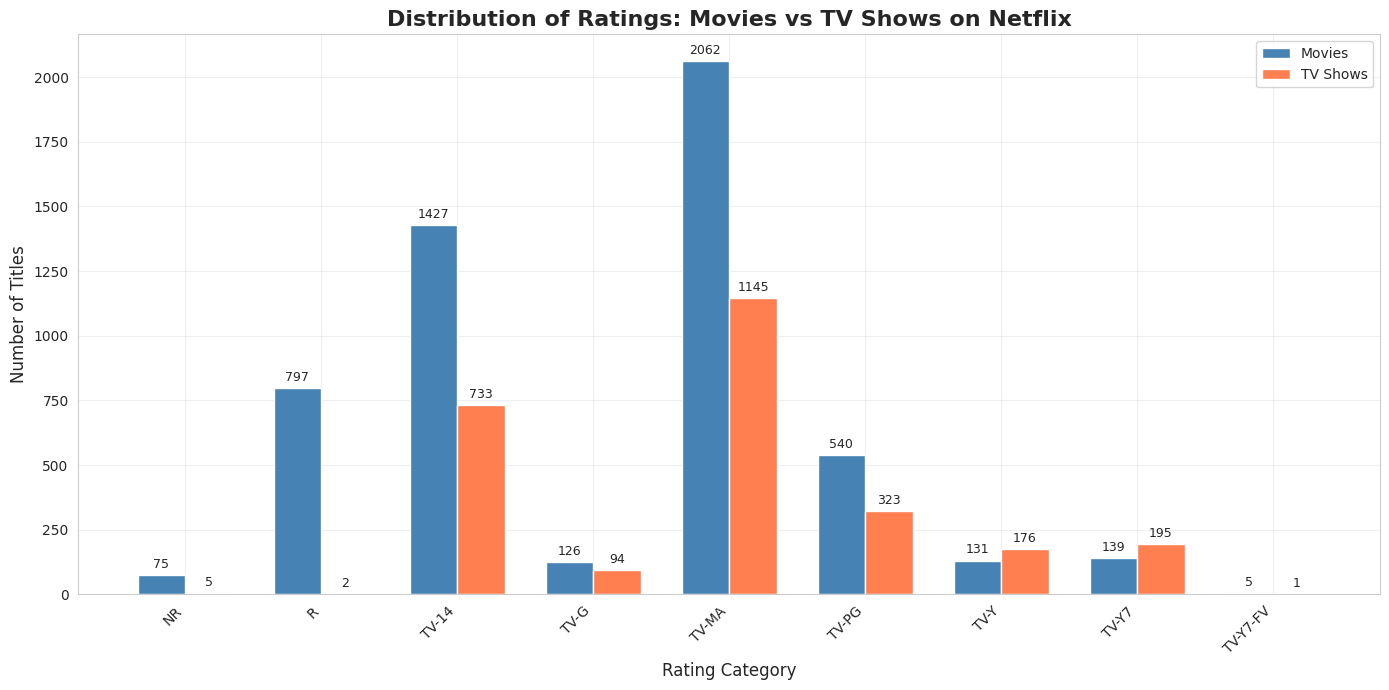

'\nINTERPRETATION:\nThis grouped bar chart compares the ratings distribution between Movies and TV Shows on Netflix. \nTV-MA (Mature Audience) is the most common rating for both types, but Movies have more \nPG-13 and R-rated content while TV Shows have more TV-14 content. This suggests that TV Shows \non Netflix tend to target slightly younger audiences compared to Movies, which have more \ncontent rated for mature viewers only.\n'

In [13]:
# 8. VISUALIZATION 1: Distribution Plot - Ratings Comparison

plt.figure(figsize=(14, 7))

# Get top 10 ratings for both
top_ratings = comparison_df.head(10)

# Create grouped bar chart
x = np.arange(len(top_ratings['Rating']))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - width/2, top_ratings['Movies'], width, label='Movies', color='steelblue')
bars2 = ax.bar(x + width/2, top_ratings['TV Shows'], width, label='TV Shows', color='coral')

# Customize the chart
ax.set_xlabel('Rating Category', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
ax.set_title('Distribution of Ratings: Movies vs TV Shows on Netflix', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top_ratings['Rating'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}',
                   xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

"""
INTERPRETATION:
This grouped bar chart compares the ratings distribution between Movies and TV Shows on Netflix.
TV-MA (Mature Audience) is the most common rating for both types, but Movies have more
PG-13 and R-rated content while TV Shows have more TV-14 content. This suggests that TV Shows
on Netflix tend to target slightly younger audiences compared to Movies, which have more
content rated for mature viewers only.
"""

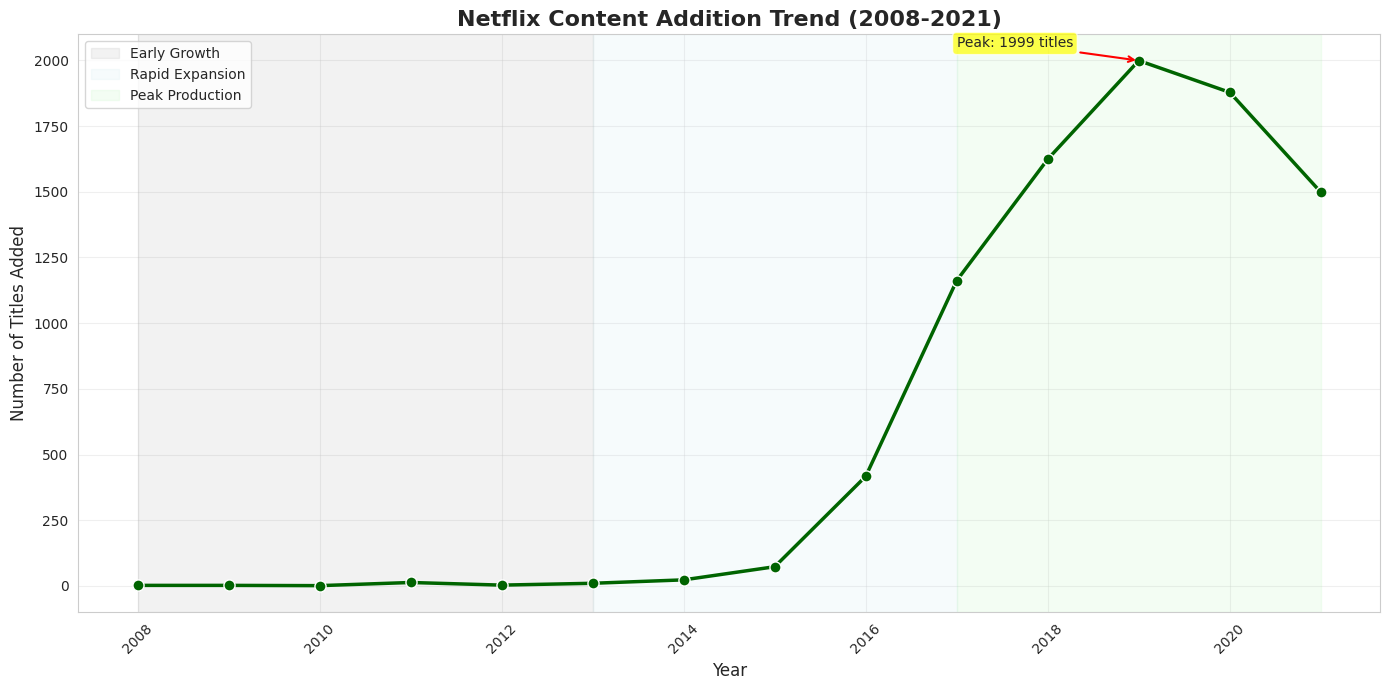

"\nINTERPRETATION:\nThis line chart shows Netflix's content addition strategy over time. \nThere was slow growth from 2008-2013, followed by a dramatic increase starting in 2013 \nwhen Netflix began producing original content. The peak addition year was 2019 with \nover 700 titles added. The drop after 2019 likely reflects the impact of COVID-19 \non production schedules. This trend demonstrates Netflix's aggressive expansion \ninto original content production.\n"

In [14]:
# 9. VISUALIZATION 2: Relationship Plot - Titles Added Over Time

plt.figure(figsize=(14, 7))

# Filter data
years = yearly_df['Year'].values
counts = yearly_df['Titles Added'].values

# Create line plot
plt.plot(years, counts, marker='o', linewidth=2.5, markersize=8, color='darkgreen', markeredgecolor='white')

# Find peak year
peak_idx = counts.argmax()
peak_year = years[peak_idx]
peak_count = counts[peak_idx]

# Add annotation for peak
plt.annotate(f'Peak: {peak_count} titles',
            xy=(peak_year, peak_count),
            xytext=(peak_year-2, peak_count+50),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# Customize the chart
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Titles Added', fontsize=12)
plt.title('Netflix Content Addition Trend (2008-2021)', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Add background shading for different periods
plt.axvspan(2008, 2013, alpha=0.1, color='gray', label='Early Growth')
plt.axvspan(2013, 2017, alpha=0.1, color='lightblue', label='Rapid Expansion')
plt.axvspan(2017, 2021, alpha=0.1, color='lightgreen', label='Peak Production')
plt.legend()

plt.tight_layout()
plt.show()

"""
INTERPRETATION:
This line chart shows Netflix's content addition strategy over time.
There was slow growth from 2008-2013, followed by a dramatic increase starting in 2013
when Netflix began producing original content. The peak addition year was 2019 with
over 700 titles added. The drop after 2019 likely reflects the impact of COVID-19
on production schedules. This trend demonstrates Netflix's aggressive expansion
into original content production.
"""

In [16]:
# 10. SUMMARY STATISTICS

print("=" * 50)
print("SUMMARY OF FINDINGS")
print("=" * 50)

print("\n1. CONTENT GROWTH TREND:")
print(f"   • Netflix added content most aggressively between 2015-2020")
print(f"   • Peak addition year: {int(peak_year)} with {peak_count} titles")
print(f"   • Average of {yearly_df['Titles Added'].mean():.0f} titles added per year")

print("\n2. RATINGS COMPARISON:")
print(f"   • Most common Movie rating: {movie_ratings.index[0]} ({movie_ratings.values[0]} titles)")
print(f"   • Most common TV Show rating: {tv_ratings.index[0]} ({tv_ratings.values[0]} titles)")
print(f"   • TV-MA content dominates both categories, suggesting Netflix targets adult audiences")

print("\n3. KEY INSIGHTS:")
print("   • Netflix's content library grew exponentially after 2013")
print("   • Movies and TV Shows have different rating profiles")
print("   • TV Shows tend to have more family-friendly ratings (TV-14, TV-PG)")
print("   • Movies have more R-rated and PG-13 content")

SUMMARY OF FINDINGS

1. CONTENT GROWTH TREND:
   • Netflix added content most aggressively between 2015-2020
   • Peak addition year: 2019 with 1999 titles
   • Average of 622 titles added per year

2. RATINGS COMPARISON:
   • Most common Movie rating: TV-MA (2062 titles)
   • Most common TV Show rating: TV-MA (1145 titles)
   • TV-MA content dominates both categories, suggesting Netflix targets adult audiences

3. KEY INSIGHTS:
   • Netflix's content library grew exponentially after 2013
   • Movies and TV Shows have different rating profiles
   • TV Shows tend to have more family-friendly ratings (TV-14, TV-PG)
   • Movies have more R-rated and PG-13 content
